In [1]:
import pandas as pd

df = pd.read_csv('cleaned_data.csv')

for col in df.columns:
    print(col) 

Date of Surgery
Sex
Age
LLIF?
Case/Type of Surgery
Perc screws?
Open
Open Check V2
Standalone XLIF Check
 Retroperitoneal Approach (LLIF ± ALIF)
Anterior + Posterior Apporoach
Osteotomies (yes/no)
osteotomy level
T12-L1
L1-L2
L2-L3
L3-L4
L4-L5
L5-S1
ALIF Count
Lateral Count
ACR (y=1)
ACR level
Additional Procedures w/in surgery
Pre op Diagnosis (back pain, adjacent segment disease, spondy)
BMI
prior back surgeries? (y=1)
Average PI
VALIDATION COLUMN
PI-LL angle mismatch
ABS PI-LL angle mismatch
PI-LL Mismatch Category (1 = mismatch > +/- 9
PI-LL Mismatch Category (1 = mismatch > +/- 10
(1 = PI>50)
Post-op SS
Post-op SS Grouping
Roussouly Class
post PI
post PT
post LL
post SVA
post-op date
most recent PI
most recent PT
most recent LL
most recent SVA
most recent date
subsidence 
titanium v PEEK (T=0,P=1)
cage details
length of hospital stay (d)
post op complications? (Y/N)
infection 1=yes
DVT  1=yes
PE  1=yes
MI 1=yes
infection 
DVT
PE
MI
Hernia
Hematoma
femoral palsy (knee extension wea

In [2]:
clean_feature_cols = [

    # Demographics
    "Sex",
    "Age",
    "BMI",
    "prior back surgeries? (y=1)",

    # Pre-op diagnosis
    "dx_adjacent_segment",
    "dx_spondylolisthesis",
    "dx_spondylosis",
    "dx_stenosis",
    "dx_scoliosis",
    "dx_flat_back",
    "dx_sagittal_imbalance",
    "dx_post_laminectomy",
    "dx_deformity",

    # Case type
    "Case/Type of Surgery",
    "Additional Procedures w/in surgery",

    # Fusion levels
    "T12-L1",
    "L1-L2",
    "L2-L3",
    "L3-L4",
    "L4-L5",
    "L5-S1",

    # Surgical approach / technique
    "Perc screws?",
    "Open",
    "Open Check V2",
    "Standalone XLIF Check",
    "Retroperitoneal Approach (LLIF ± ALIF)",
    "Anterior + Posterior Apporoach",
    "Osteotomies (yes/no)",
    "osteotomy level",
    "ALIF Count",
    "Lateral Count",
    "ACR (y=1)",
    "ACR level",

    # Preoperative spinopelvic parameters
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "PI-LL Mismatch Category (1 = mismatch > +/- 9",
    "PI-LL Mismatch Category (1 = mismatch > +/- 10",
    "(1 = PI>50)",

    # Immediate postoperative alignment (allowed)
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",

    # Immediate postop complications (allowed)
    "infection 1=yes",
    "DVT  1=yes",
    "PE  1=yes",
    "MI 1=yes",
    "femoral palsy (knee extension weakness) 1=yes",
    "hip flexion weakness (iliopsoas weakness)  1=yes",
    "acute thigh paresthesia (immediate post op)",
    "psoas hematoma",

    # Hospital course
    "length of hospital stay (d)",
]


In [3]:
clean_feature_cols_asd = [

    # -----------------
    # Demographics
    # -----------------
    "Sex",
    "Age",
    "BMI",
    "prior back surgeries? (y=1)",

    # -----------------
    # Pre-op diagnosis flags (from Pre op Diagnosis text)
    # -----------------
    "dx_adjacent_segment",
    "dx_spondylolisthesis",
    "dx_spondylosis",
    "dx_stenosis",
    "dx_scoliosis",
    "dx_flat_back",
    "dx_sagittal_imbalance",
    "dx_post_laminectomy",
    "dx_deformity",
    "Case/Type of Surgery",


    # -----------------
    # Fusion levels (index constructs)
    # -----------------
    "T12-L1",
    "L1-L2",
    "L2-L3",
    "L3-L4",
    "L4-L5",
    "L5-S1",

    # Construct summary features you engineered
    "levels_fused_count",
    "construct_span_levels",
    "thoracolumbar_junction",
    "upper_lumbar",
    "lower_lumbar",
    "lumbosacral",

    # -----------------
    # Surgical approach / technique
    # -----------------
    "LLIF?",                # whether lateral/LLIF was done at all
    "Perc screws?",
    "Open",
    "Open Check V2",
    "Standalone XLIF Check",
    "Retroperitoneal Approach (LLIF ± ALIF)",
    "Anterior + Posterior Apporoach",
    "Osteotomies (yes/no)",
    "osteotomy level",
    "ALIF Count",
    "Lateral Count",
    "ACR (y=1)",
    "ACR level",

    # Higher-level surgery flags
    "revision_surgery",
    "deformity_case_text",
    "llif_or_lateral_text",
    "xlif_text",
    "alif_text",

    # -----------------
    # Preoperative spinopelvic parameters
    # -----------------
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "PI-LL Mismatch Category (1 = mismatch > +/- 9",
    "PI-LL Mismatch Category (1 = mismatch > +/- 10",
    "(1 = PI>50)",   # this matches your full column list

    # -----------------
    # Immediate postoperative alignment (non-leaky)
    # -----------------
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",

    # -----------------
    # Immediate postop complications (index hospitalization)
    # -----------------
    "infection 1=yes",
    "DVT  1=yes",
    "PE  1=yes",
    "MI 1=yes",
    "femoral palsy (knee extension weakness) 1=yes",
    "hip flexion weakness (iliopsoas weakness)  1=yes",
    "acute thigh paresthesia (immediate post op)",
    "psoas hematoma",

    # -----------------
    # Hospital course
    # -----------------
    "length of hospital stay (d)",
]


In [4]:
import pandas as pd
import numpy as np
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

time_col = "Time Until ASD Diagnosis (months)"


C:\Users\shrin\AppData\Local\Temp\ipykernel_48192\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\shrin\AppData\Local\Temp\ipykernel_48192\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\shrin\AppData\Local\Temp\ipykernel_48192\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")


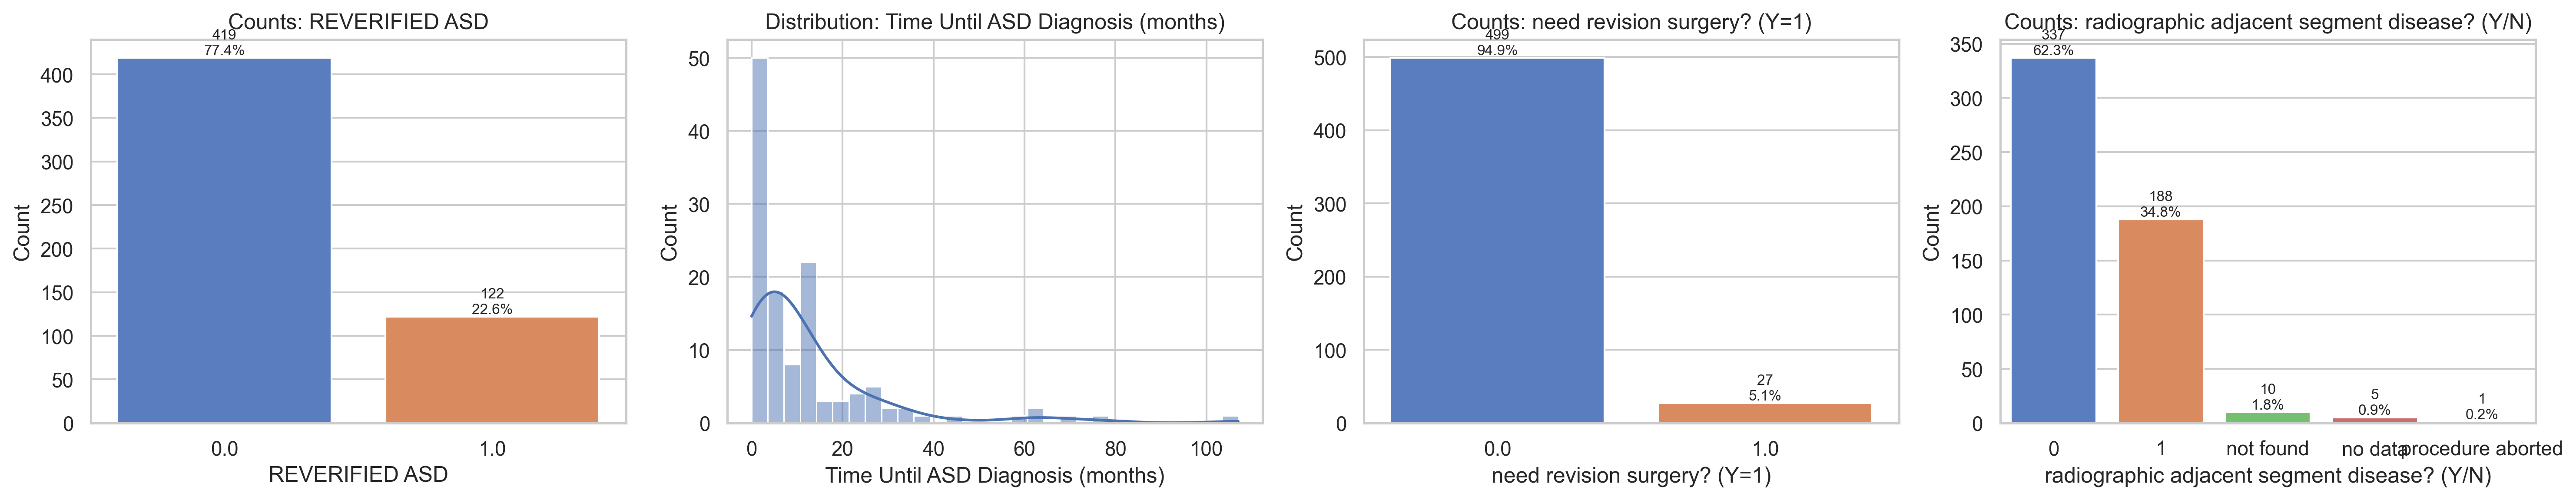

In [5]:
import seaborn as sns
from pandas.api import types as pd_types

import matplotlib.pyplot as plt

# helper to find column with case-insensitive / partial matching
def find_col(df, name):
    name_l = name.lower()
    # exact lower match
    for c in df.columns:
        if c.lower() == name_l:
            return c
    # substring match
    for c in df.columns:
        if name_l in c.lower() or c.lower() in name_l:
            return c
    return None

# desired columns (use existing notebook variables where available)
cols_wanted = [
    "REVERIFIED ASD",                    # user: 'Reverified ASD'
    time_col,                            # 'Time Until ASD Diagnosis (months)' (variable from notebook)
    "need revision surgery? (Y=1)",      # user-provided name
    "radiographic adjacent segment disease? (Y/N)"
]

# resolve to actual df columns, skip missing
cols = []
for nm in cols_wanted:
    c = find_col(df, nm)
    if c is None:
        print(f"Column not found (skipping): {nm}")
    else:
        cols.append(c)

if not cols:
    raise RuntimeError("No plotting columns found in df.")

sns.set(style="whitegrid")

n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), dpi=300, squeeze=False)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    series = df[col].dropna()
    # decide continuous vs categorical/binary
    is_numeric = pd_types.is_numeric_dtype(series.dtype)
    unique_vals = series.nunique(dropna=True)
    if is_numeric and unique_vals > 10:
        # distribution for continuous
        sns.histplot(series.astype(float), kde=True, bins=30, ax=ax, color="C0")
        ax.set_title(f"Distribution: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    else:
        # histogram / countplot for categorical / binary
        order = series.value_counts(dropna=True).index
        sns.countplot(x=series, order=order, ax=ax, palette="muted")
        ax.set_title(f"Counts: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        # annotate counts / percentages
        totals = len(series)
        for p in ax.patches:
            height = p.get_height()
            if height == 0:
                continue
            pct = 100 * height / totals
            ax.annotate(f"{int(height)}\n{pct:.1f}%", (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd


# 2. Clean column names a bit
df.columns = (
    df.columns
      .str.strip()
      .str.replace("\n", " ", regex=False)
)

df.columns



Index(['Date of Surgery', 'Sex', 'Age', 'LLIF?', 'Case/Type of Surgery',
       'Perc screws?', 'Open', 'Open Check V2', 'Standalone XLIF Check',
       'Retroperitoneal Approach (LLIF ± ALIF)',
       ...
       'alif_text', 'dx_adjacent_segment', 'dx_spondylolisthesis',
       'dx_spondylosis', 'dx_stenosis', 'dx_scoliosis', 'dx_flat_back',
       'dx_sagittal_imbalance', 'dx_post_laminectomy', 'dx_deformity'],
      dtype='str', length=116)

In [7]:
target = "Time Until ASD Diagnosis (months)"

# Keep only rows where the target is known (patients who actually developed ASD)
asd_df = df[df[target].notna()].copy()
asd_df.shape


(125, 116)

In [8]:
# -----------------------------
# Final pipeline: feature prep -> PCA -> RSF (fixed best params) -> metrics + save + unit test
# -----------------------------
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, integrated_brier_score, cumulative_dynamic_auc
from lifelines import KaplanMeierFitter

# -----------------------------
# 0. CONFIG: best RSF params 
# -----------------------------
BEST_RSFPARAMS = {
    "n_estimators": 200,
    "min_samples_split": 4,
    "min_samples_leaf": 12,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42,
}

# -----------------------------
# 1. Survival labels & basic checks (assumes df available)
# -----------------------------
event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"

df_surv = df.copy()
df_surv[event_col] = df_surv.get(event_col, 0).fillna(0).astype(int)
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv.get(time_asd_col),
    df_surv.get(time_no_asd_col),
)
df_surv = df_surv.dropna(subset=["time_surv"])
df_surv["time_surv"] = df_surv["time_surv"].astype(float)

print("Cohort rows:", df_surv.shape[0], "Events:", int(df_surv[event_col].sum()))

# -----------------------------
# 2. Feature construction 
# -----------------------------
# clean_feature_cols must exist (list of features you'd like to start from)
X = df_surv[clean_feature_cols].copy()

numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

# coerce numeric-like
for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# one-hot encode categoricals
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical feature columns:", cat_cols)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# simple imputation
X_encoded = X_encoded.fillna(0.0)

# targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Initial feature matrix shape:", X_encoded.shape)

# -----------------------------
# 3. Remove ultra-rare binary features (occurence < 5)
# -----------------------------
binary_like_cols = [c for c in X_encoded.columns if set(np.unique(X_encoded[c])) <= {0,1}]
rare_cols = [c for c in binary_like_cols if X_encoded[c].sum() < 5]
print(f"Dropping {len(rare_cols)} ultra-rare binary cols.")
X_reduced = X_encoded.drop(columns=rare_cols)
print("Shape after dropping ultra-rare columns:", X_reduced.shape)

# -----------------------------
# 4. PCA compression 
# -----------------------------
numeric_present = [c for c in numeric_like_cols if c in X_reduced.columns]
print("Numeric-like columns for PCA:", numeric_present)

if len(numeric_present) >= 2:
    scaler_for_pca = StandardScaler()
    numeric_data = scaler_for_pca.fit_transform(X_reduced[numeric_present].values)
    n_pca = min(3, numeric_data.shape[1])
    pca = PCA(n_components=n_pca, random_state=42)
    pcs = pca.fit_transform(numeric_data)
    pca_cols = [f"pca_num_{i+1}" for i in range(n_pca)]
    df_pcs = pd.DataFrame(pcs, columns=pca_cols, index=X_reduced.index)
    X_reduced = pd.concat([X_reduced.drop(columns=numeric_present), df_pcs], axis=1)
    print(f"Replaced {len(numeric_present)} numeric cols with {n_pca} PCA components.")
else:
    print("Skipping PCA (not enough numeric-like columns).")

print("Final feature matrix shape (X_reduced):", X_reduced.shape)

import pickle
import numpy as np
import pandas as pd
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Load trained model
with open("models/rsf_final_best.pkl", "rb") as f:
    bundle = pickle.load(f)

rsf = bundle["model"]
feature_cols = bundle["feature_columns"]


Cohort rows: 546 Events: 122
Categorical feature columns: ['Case/Type of Surgery', 'Additional Procedures w/in surgery', 'osteotomy level', 'ACR level']
Initial feature matrix shape: (546, 424)
Dropping 354 ultra-rare binary cols.
Shape after dropping ultra-rare columns: (546, 70)
Numeric-like columns for PCA: ['BMI', 'ALIF Count', 'Lateral Count', 'Average PI', 'PI-LL angle mismatch', 'ABS PI-LL angle mismatch', 'Post-op SS', 'post PI', 'post PT', 'post LL', 'post SVA', 'length of hospital stay (d)']
Replaced 12 numeric cols with 3 PCA components.
Final feature matrix shape (X_reduced): (546, 61)


C:\Users\shrin\AppData\Local\Temp\ipykernel_48192\1042527084.py:78: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [9]:

# Recreate training matrix EXACTLY as before
# (IMPORTANT: must match training pipeline)
X = X_reduced.copy()          # from your training notebook
X = X[feature_cols]
X_vals = X.values

events = events_all
times = durations_all


In [10]:
import numpy as np
import pandas as pd
from sksurv.metrics import concordance_index_censored

def permutation_importance_survival(
    model, X, events, times, n_repeats=10, random_state=42
):
    rng = np.random.RandomState(random_state)

    base_pred = model.predict(X)
    base_ci = concordance_index_censored(events, times, base_pred)[0]

    importances = []

    for j in range(X.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            perm_idx = rng.permutation(len(X))
            X_perm[:, j] = X_perm[perm_idx, j]

            pred_perm = model.predict(X_perm)
            ci_perm = concordance_index_censored(events, times, pred_perm)[0]
            drops.append(base_ci - ci_perm)

        importances.append(np.mean(drops))

    return np.array(importances)


In [11]:
imp = permutation_importance_survival(
    rsf, X_vals, events, times, n_repeats=10
)

imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": imp
}).sort_values("importance", ascending=False)

imp_df.head(20)


,feature,importance
1,Age,0.038399
60,pca_num_3,0.034676
59,pca_num_2,0.033865
58,pca_num_1,0.027350
6,dx_stenosis,0.009547
2,prior back surgeries? (y=1),0.006667
8,dx_flat_back,0.006356
0,Sex,0.006356
21,(1 = PI>50),0.005909
4,dx_spondylolisthesis,0.005662


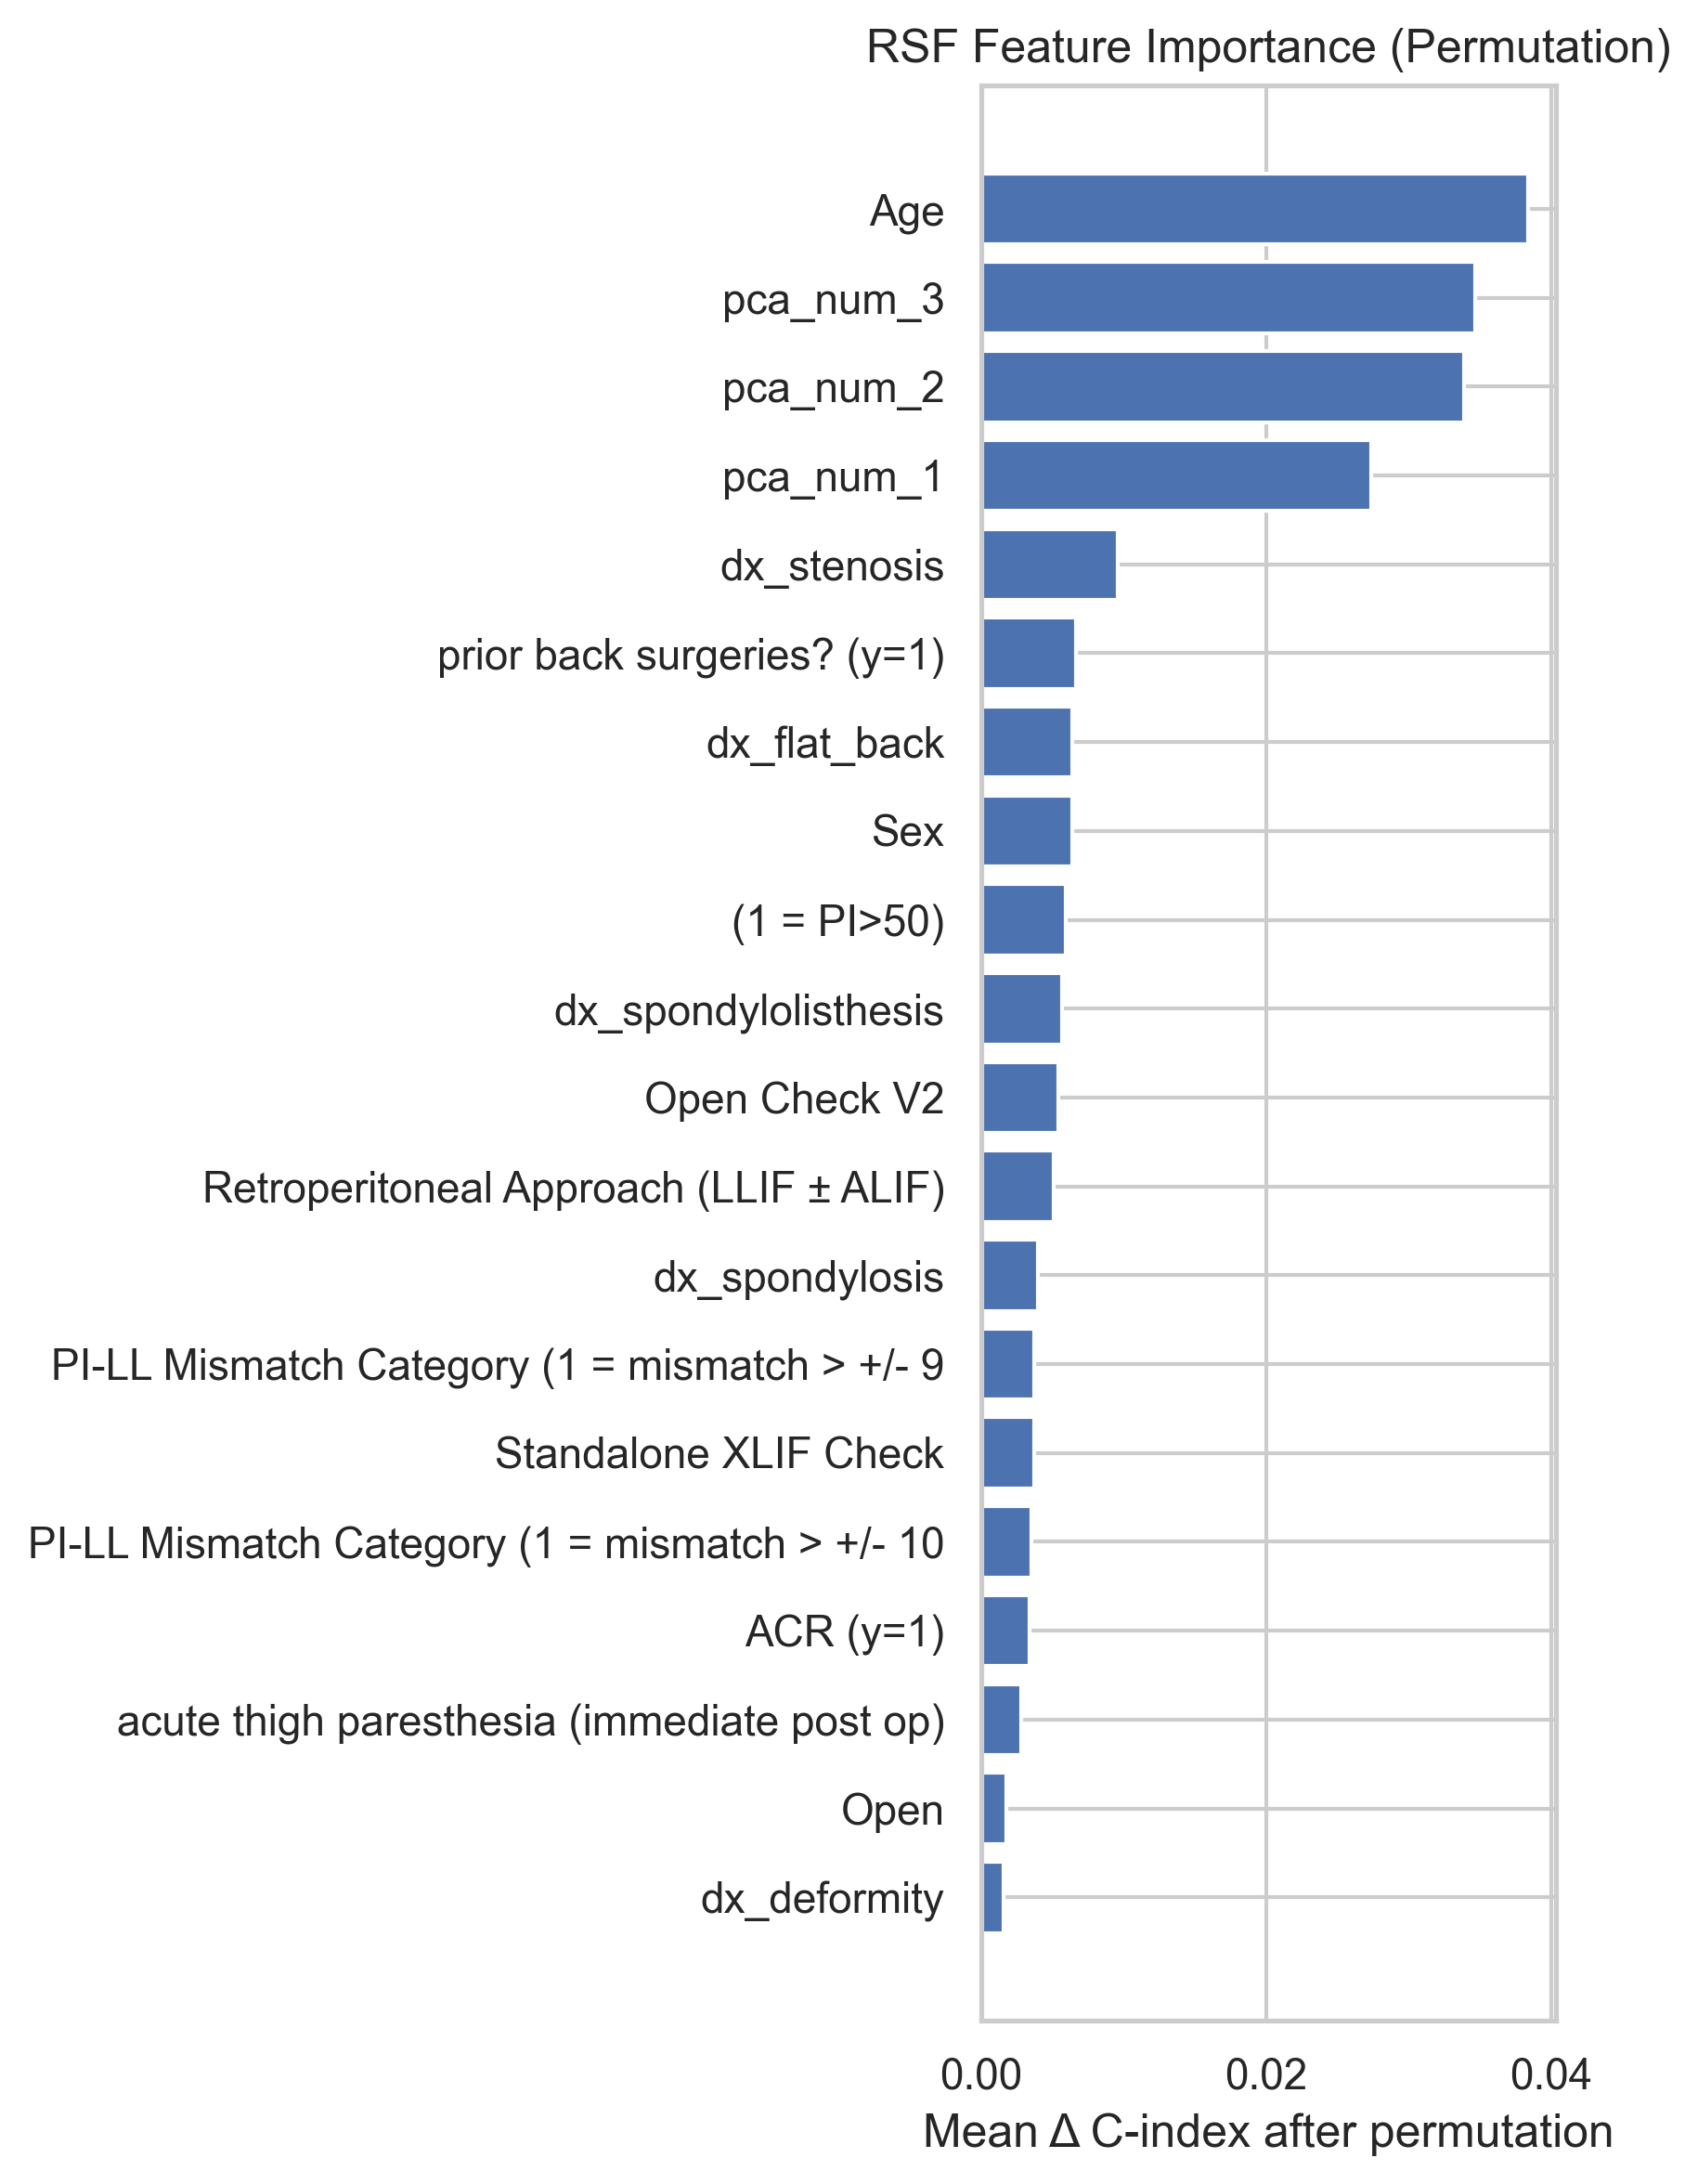

In [12]:
import matplotlib.pyplot as plt

top_k = 20
plt.figure(figsize=(6,8), dpi=300)
plt.barh(
    imp_df.head(top_k)["feature"][::-1],
    imp_df.head(top_k)["importance"][::-1]
)
plt.xlabel("Mean Δ C-index after permutation")
plt.title("RSF Feature Importance (Permutation)")
plt.tight_layout()
plt.show()


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# Extract the numeric matrix exactly as before
X_num = X_encoded[numeric_like_cols].copy()

# Impute if needed (should already be clean)
X_num = X_num.fillna(0.0)

# Standardize (PCA requires this)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Fit PCA with same n_components
pca = PCA(n_components=3, random_state=42)
pca.fit(X_num_scaled)


,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_like_cols,
    columns=["pca_num_1", "pca_num_2", "pca_num_3"]
)

loadings


,pca_num_1,pca_num_2,pca_num_3
BMI,-0.011578,-0.046695,-0.009121
ALIF Count,0.019189,0.439684,0.072830
Lateral Count,-0.026005,0.632283,0.013779
Average PI,0.357327,-0.051251,-0.085626
PI-LL angle mismatch,0.268595,-0.073455,0.696850
ABS PI-LL angle mismatch,0.361861,0.000976,0.420611
Post-op SS,0.402732,0.073550,-0.260185
post PI,0.417072,0.012626,-0.194579
post PT,0.406581,-0.001429,0.128381
post LL,0.386639,0.088422,-0.436547


In [15]:
def summarize_pca(loadings, pc, top_k=6):
    s = loadings[pc]
    return s.reindex(s.abs().sort_values(ascending=False).index).head(top_k)

summarize_pca(loadings, "pca_num_1")


post PI                     0.417072
post PT                     0.406581
Post-op SS                  0.402732
post LL                     0.386639
ABS PI-LL angle mismatch    0.361861
Average PI                  0.357327
Name: pca_num_1, dtype: float64

In [16]:
summarize_pca(loadings, "pca_num_2")



Lateral Count                  0.632283
length of hospital stay (d)    0.615466
ALIF Count                     0.439684
post LL                        0.088422
Post-op SS                     0.073550
PI-LL angle mismatch          -0.073455
Name: pca_num_2, dtype: float64

In [17]:
summarize_pca(loadings, "pca_num_3")

PI-LL angle mismatch        0.696850
post LL                    -0.436547
ABS PI-LL angle mismatch    0.420611
Post-op SS                 -0.260185
post PI                    -0.194579
post PT                     0.128381
Name: pca_num_3, dtype: float64